# Practica 04: Analisis de Datos Exploratorios con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa  de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026


### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Adriana Rosales Gayosso \
**Matricula:** 230671 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #D4EDDA 0%, #E6E6FA 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">

<h1 style="color: #E0F7FA; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #DB7093; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

---

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1) | Librerias, carga del CSV, primeros comandos de escritura |
| 2 | [Diccionario de Datos](#s2) | Explicación del contenido de columnas y calcular el % de datos faltantes |
| 3 | [Limpieza de datos](#s2) | Aplicasion de metodos basicos de limpieza (eliminacion duplicados, agrupacion, datos nulos) |

## 1. Instalaciones & Carga de Datos <a id='s1'></a>
<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [10]:
# ============================================================
# SECTION 1 - Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

#ML - Machine learning- Entrenamiento de modelos matematicos para predecir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅ Pandas   : {pd.__version__}')
print(f'✅ NumPy    : {np.__version__}')
print('✅ Todas la librerías cargaron con éxito!')

✅ Pandas   : 2.3.3
✅ NumPy    : 2.3.5
✅ Todas la librerías cargaron con éxito!


In [11]:
# Load dataset

df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f' Shape   : {df_raw.shape}')
print(f' Columns : {df_raw.columns.tolist()}')

df_raw.head(3)

 Shape   : (1455, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame.

In [12]:
# Column dictionary
col_info = {
    'rl': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor ',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes ... )',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
}
print('Diccionario por columnas:')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() *100
    print(
        f' {col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
)

Diccionario por columnas:
 rl                   | URL del Producto en Amazon.in                 | Missing: 0%
 asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
 name                 | Nombre o Título del Producto                  | Missing: 0%
 overview             | Breve Reseña del Producto (mayoría vacío [])  | Missing: 0%
 price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
 currency             | Código de Divisa (todas en INR)               | Missing: 24%
 availability         | Texto del Status del Stock (Inventario)       | Missing: 34%
 brand                | Nombre de la Marca/Autor                      | Missing: 1%
 about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
 img_source           | URLs de Imágenes del Producto                 | Missing: 1%
 description          | Descripción detallada y completa (mayoría fal | Missing: 92%
 specifications       | Especificaciones Técn

## 3. Limpieza de Datos

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [13]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,103 / 1,455 products
✅ Duplicate ASINs: 15
✅ Availability categories: {'In Stock': 607, 'Unknown': 493, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


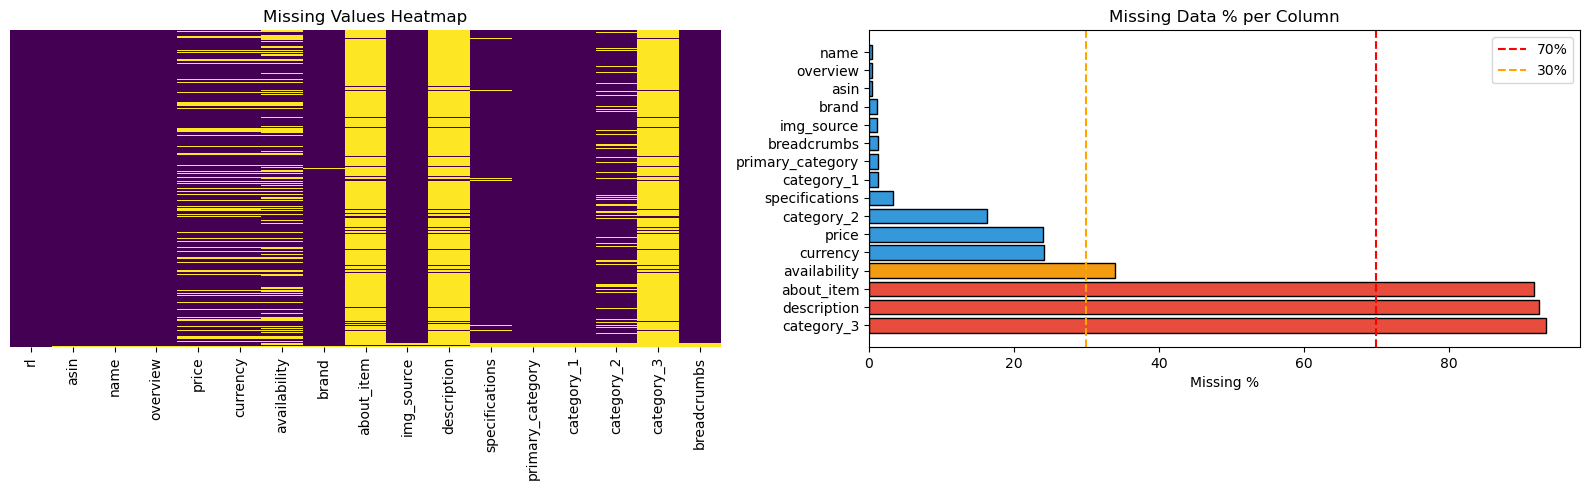

                  Missing Count  Missing Pct
category_3                 1359         93.4
description                1345         92.4
about_item                 1334         91.7
availability                493         33.9
currency                    350         24.1
price                       349         24.0
category_2                  237         16.3
specifications               48          3.3
category_1                   19          1.3
primary_category             19          1.3
breadcrumbs                  19          1.3
img_source                   16          1.1
brand                        16          1.1
asin                          6          0.4
overview                      6          0.4
name                          6          0.4


In [14]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de caracteristicas (Feature Engineering)

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
    <b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [15]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total de Funciones totales diseñadas : {len(df.columns)}')
print('\nDistribución por niveles de precios:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


✅ Total de Funciones totales diseñadas : 39

Distribución por niveles de precios:
price_tier
1_budget     105
2_low        285
3_mid        319
4_premium    268
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 4. Análisis Univariado 📊 <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo se ve la distribución del precio? ¿Hay valores atípicos (outliers)? ¿Los datos presentan algún sesgo?
</div>

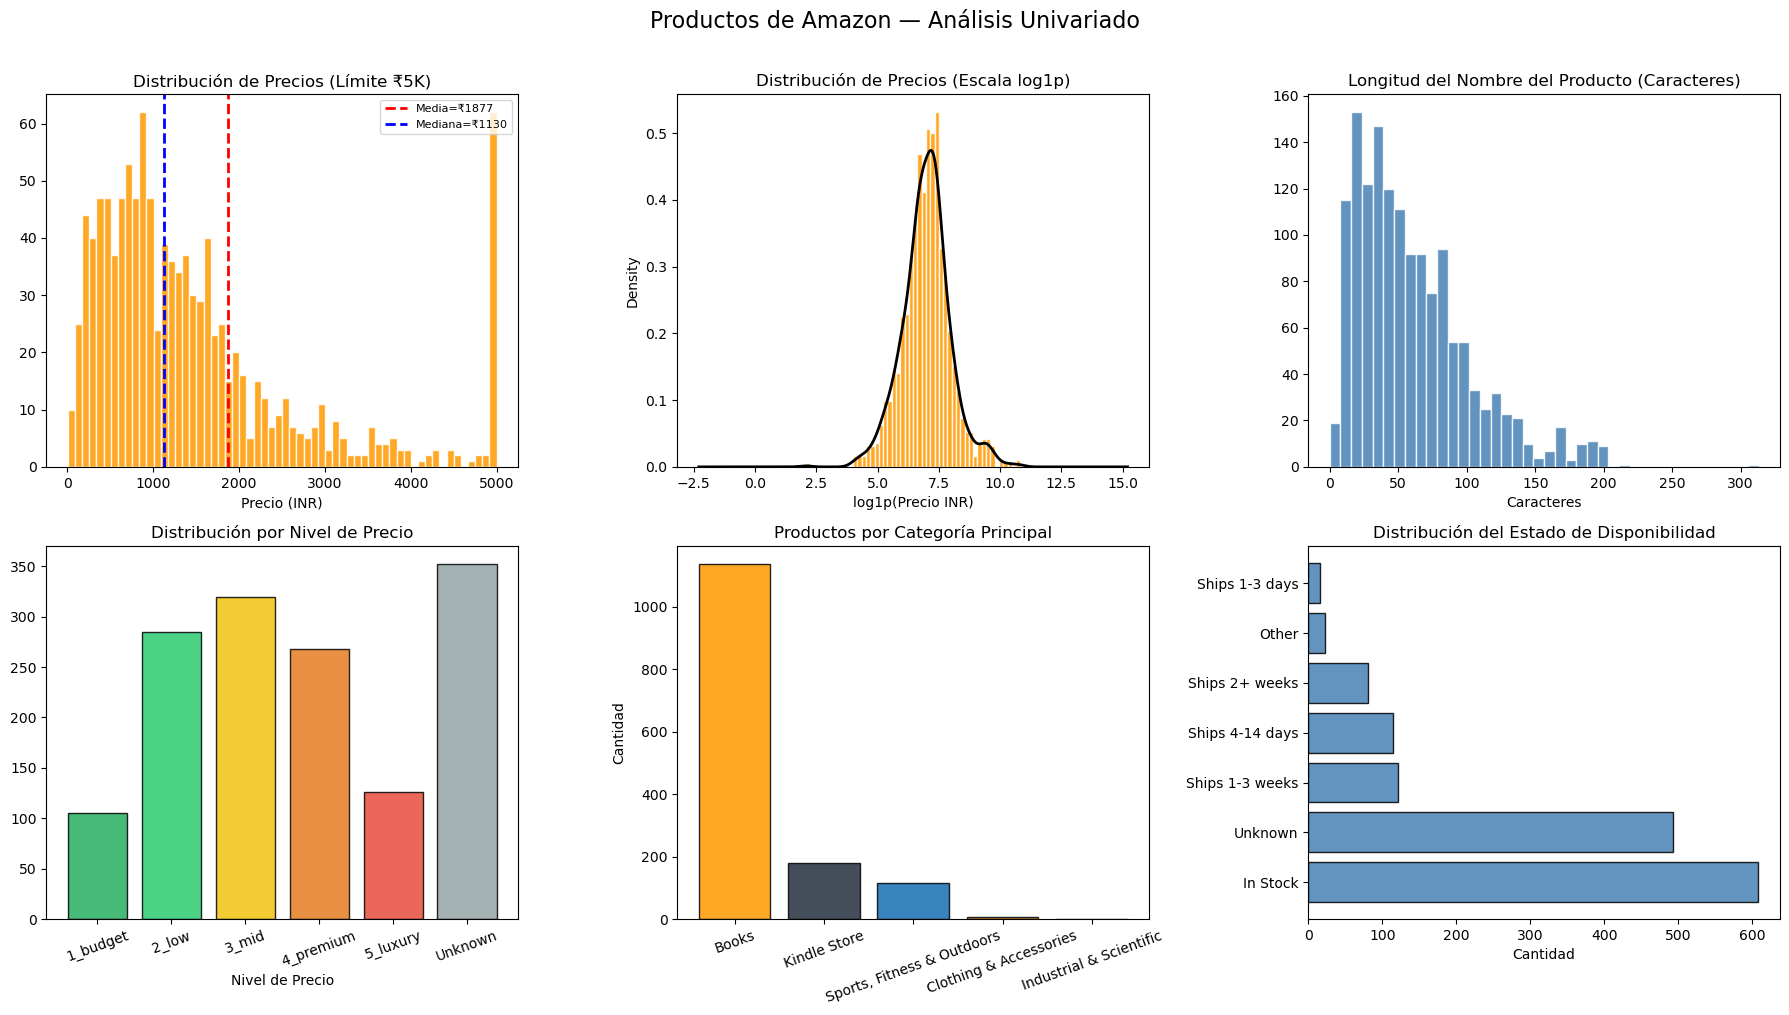

Prueba de Shapiro-Wilk (log precio, n=500): estadístico=0.9887, p-valor=0.000677
Resultado: El precio sigue teniendo una distribución NO normal después de la transformación logarítmica

Estadísticas descriptivas del precio (INR):
count     1096.00
mean      1876.68
std       3326.26
min          7.00
25%        616.76
50%       1130.50
75%       1836.13
max      50555.00


In [17]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================
import matplotlib.pyplot as plt
from scipy.stats import shapiro  # Corrección: Asegura la importación para la prueba de normalidad

# Filtrar filas donde el precio limpio no sea nulo y sea mayor a 0
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

# Crear una cuadrícula de gráficos de 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Gráfico: Distribución del Precio Original (Límite de ₹5K)
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Media=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Mediana=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Distribución de Precios (Límite ₹5K)')
axes[0,0].set_xlabel('Precio (INR)')
axes[0,0].legend(fontsize=8)

# 2. Gráfico: Distribución del Logaritmo del Precio
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Distribución de Precios (Escala log1p)')
axes[0,1].set_xlabel('log1p(Precio INR)')

# 3. Gráfico: Longitud del Nombre del Producto
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Longitud del Nombre del Producto (Caracteres)')
axes[0,2].set_xlabel('Caracteres')

# 4. Gráfico: Distribución por Nivel de Precio
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Distribución por Nivel de Precio')
axes[1,0].set_xlabel('Nivel de Precio')
axes[1,0].tick_params(axis='x', rotation=20)

# 5. Gráfico: Productos por Categoría Principal
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', rotation=20)

# 6. Gráfico: Distribución del Estado de Disponibilidad
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad')

# Título global de la figura
plt.suptitle('Productos de Amazon — Análisis Univariado', fontsize=16, y=1.01)
plt.tight_layout()

# Nota: Si estás en un entorno local o Jupyter Notebook, usa plt.show() para visualizarlo directamente:
plt.show()
# Si prefieres guardarlo como imagen, puedes descomentar la siguiente línea:
# plt.savefig('analisis_univariado_amazon.png')

# ============================================================
# PRUEBA DE NORMALIDAD Y ESTADÍSTICAS
# ============================================================
# Tomar una muestra de 500 registros para la prueba de Shapiro-Wilk
muestra_log_precio = df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42)
stat, p = shapiro(muestra_log_precio)

print(f'Prueba de Shapiro-Wilk (log precio, n=500): estadístico={stat:.4f}, p-valor={p:.6f}')
print(f'Resultado: El precio {"tiene una distribución normal después de la transformación logarítmica" if p > 0.05 else "sigue teniendo una distribución NO normal después de la transformación logarítmica"}')

print(f'\nEstadísticas descriptivas del precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())


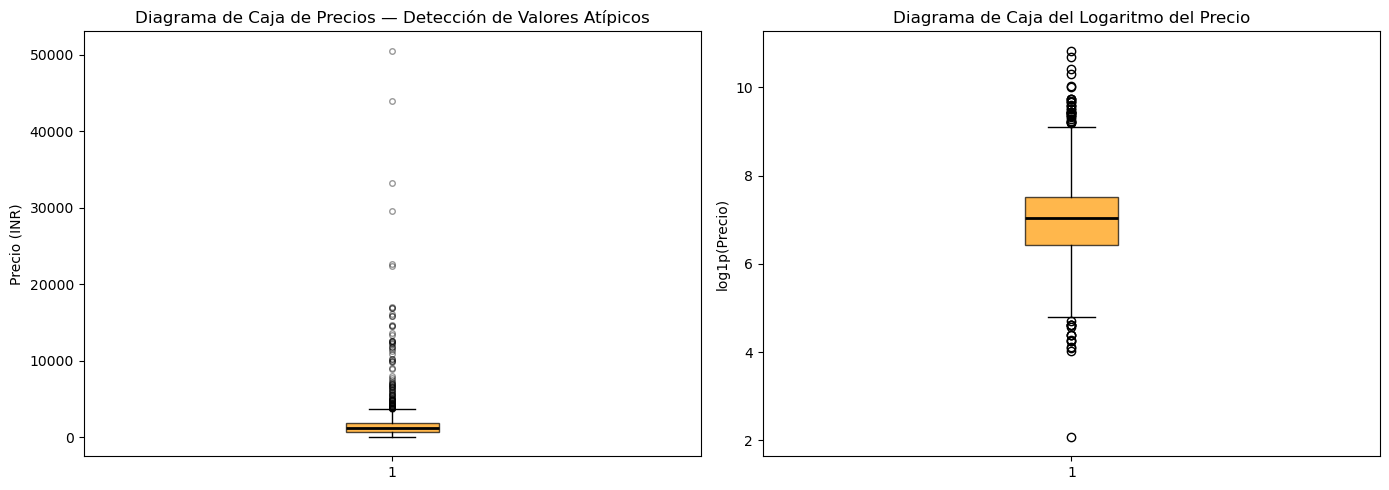

Valores atípicos detectados por el método IQR: 93 (8.5%)
Rango de precios normales (sin valores atípicos): ₹-1212 – ₹3665

Top 10 de los productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds

In [18]:
# Análisis de valores atípicos (outliers) — diagrama de caja (boxplot) y rango intercuartílico (IQR)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico: Diagrama de Caja del Precio Original
axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Diagrama de Caja de Precios — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR)')

# 2. Gráfico: Diagrama de Caja del Logaritmo del Precio
axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Diagrama de Caja del Logaritmo del Precio')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

# Cálculo del Rango Intercuartílico (IQR) para identificar valores atípicos
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]

# Impresión de resultados en la consola
print(f'Valores atípicos detectados por el método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precios normales (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 de los productos más caros:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))


## 5. Análisis por Categorías 🗂️ <a id='s5'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se concentra el mayor valor comercial?
</div>

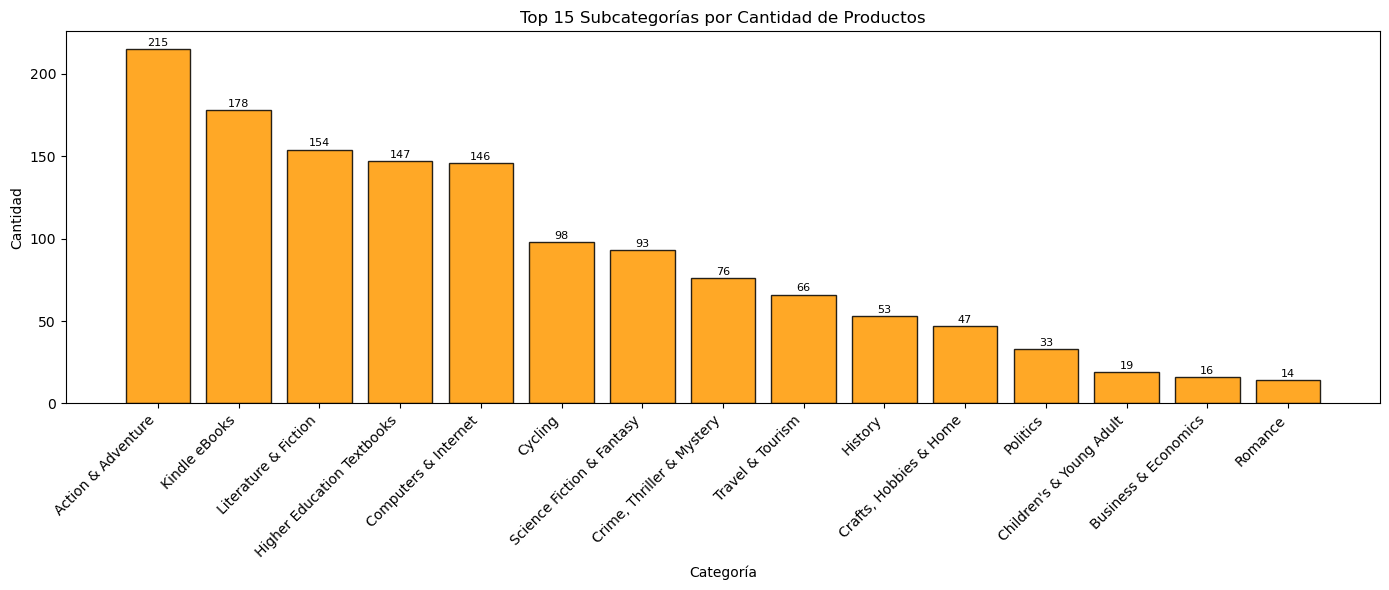

In [20]:
# ============================================================
# SECCIÓN 5 — Análisis por Categorías
# ============================================================
# Top 15 subcategorías por cantidad de productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# Añadir las etiquetas con el valor encima de cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontsize=8)

plt.title('Top 15 Subcategorías por Cantidad de Productos')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Nota: Usa plt.show() en tu Jupyter Notebook para visualizarlo
plt.show()
# O descompón la siguiente línea si deseas guardarlo como imagen:
# plt.savefig('top15_subcategorias.png')

C:\Users\PC-13\AppData\Local\Temp\ipykernel_15392\3927140235.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


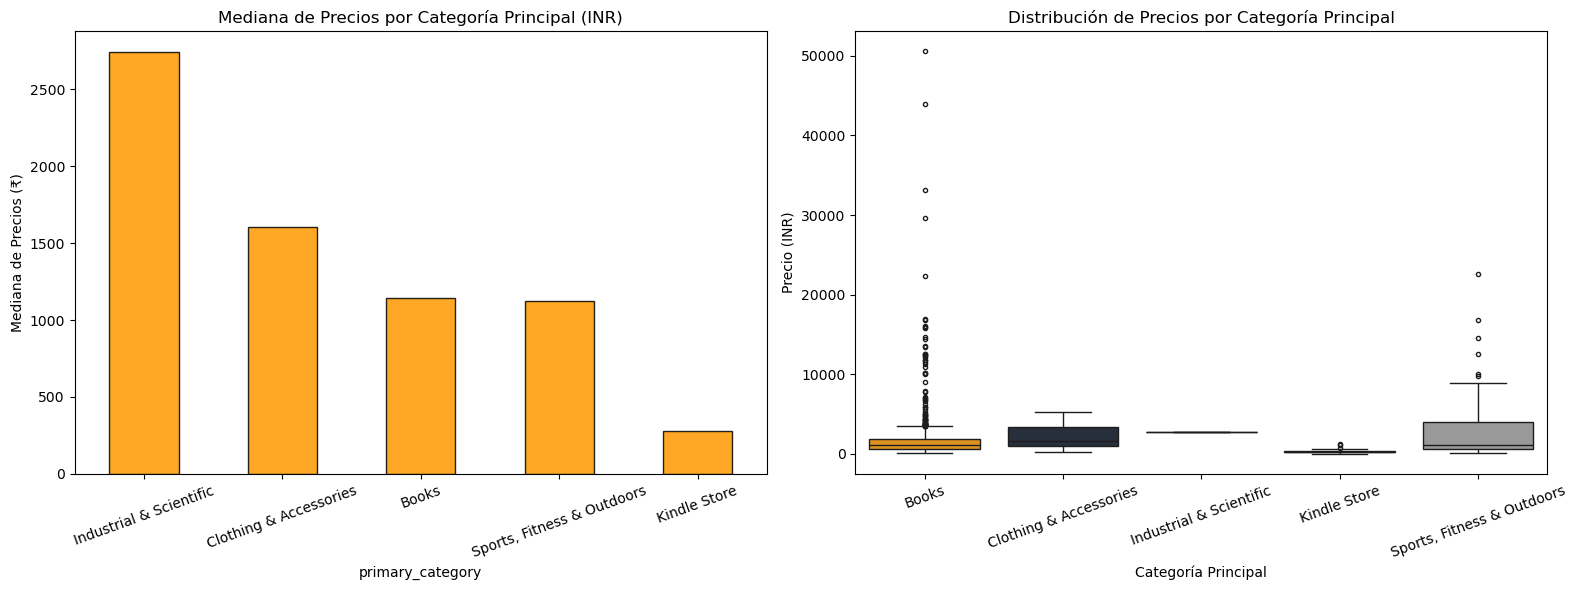

Estadísticas de precios por categoría principal:
                             Media  Mediana  Cantidad
primary_category                                     
Books                       1825.6   1145.0       955
Clothing & Accessories      2249.2   1606.5         6
Industrial & Scientific     2738.0   2738.0         1
Kindle Store                 350.0    281.4        30
Sports, Fitness & Outdoors  2907.9   1125.0        93


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el tamaño de la figura (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Agrupar por categoría principal y calcular estadísticas de precios
cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
orden_categorias = cat_price.index.tolist() # Convertimos el índice a una lista limpia

# 2. Gráfico Izquierdo: Mediana de Precios por Categoría
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precios por Categoría Principal (INR)')
axes[0].set_ylabel('Mediana de Precios (₹)')
axes[0].tick_params(axis='x', rotation=20)

# 3. Gráfico Derecho: Diagrama de caja (Boxplot) corregido y compatible
# Definimos los colores exactos para cada categoría en un diccionario para evitar el ValueError
colores_amazon = ['#FF9900', '#232F3E', '#146EB4', '#E47911', '#999999']
paleta_mapeada = dict(zip(orden_categorias, colores_amazon[:len(orden_categorias)]))

sns.boxplot(
    data=df_priced, 
    x='primary_category', 
    y='price_clean', 
    ax=axes[1], 
    order=orden_categorias,
    palette=paleta_mapeada,  # Usar el diccionario mapeado soluciona el error de NumPy
    fliersize=3
)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_xlabel('Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Renombrar columnas solo para la visualización final del print en español
cat_price_es = cat_price.rename(columns={'mean': 'Media', 'median': 'Mediana', 'count': 'Cantidad'})
print('Estadísticas de precios por categoría principal:')
print(cat_price_es.to_string())

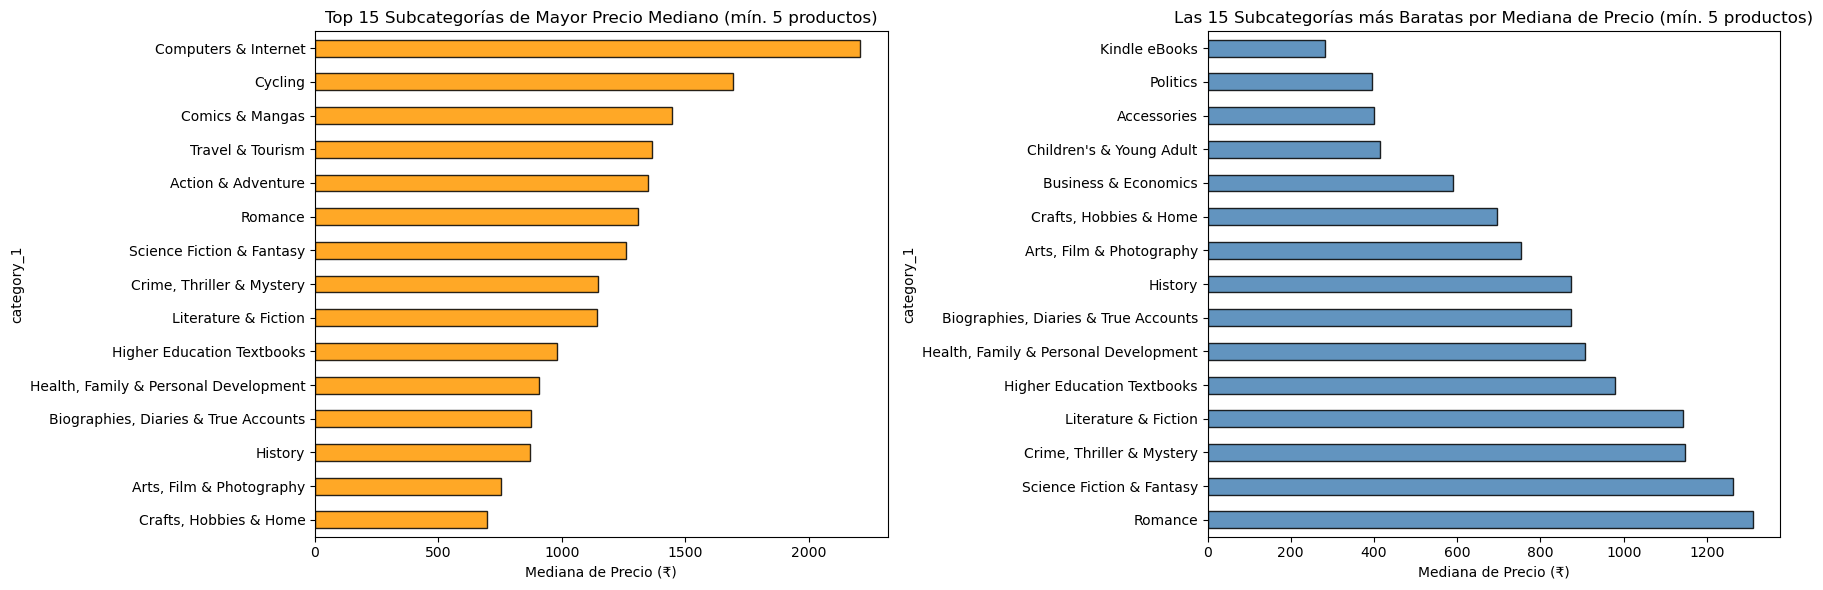

In [22]:
# Top 15 subcategorías por mediana de precio
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

# Crear una cuadrícula con 2 gráficos horizontales (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Gráfico: Las 15 subcategorías más caras
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Subcategorías de Mayor Precio Mediano (mín. 5 productos)')
axes[0].set_xlabel('Mediana de Precio (₹)')

# 2. Gráfico: Las 15 subcategorías más baratas (menor precio mediano)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))

bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Las 15 Subcategorías más Baratas por Mediana de Precio (mín. 5 productos)')
axes[1].set_xlabel('Mediana de Precio (₹)')

plt.tight_layout()
plt.show()

## 6. Análisis de Disponibilidad 📦 <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Afecta el estado de disponibilidad al precio de los productos? ¿Es más probable que los productos premium estén agotados?
</div>

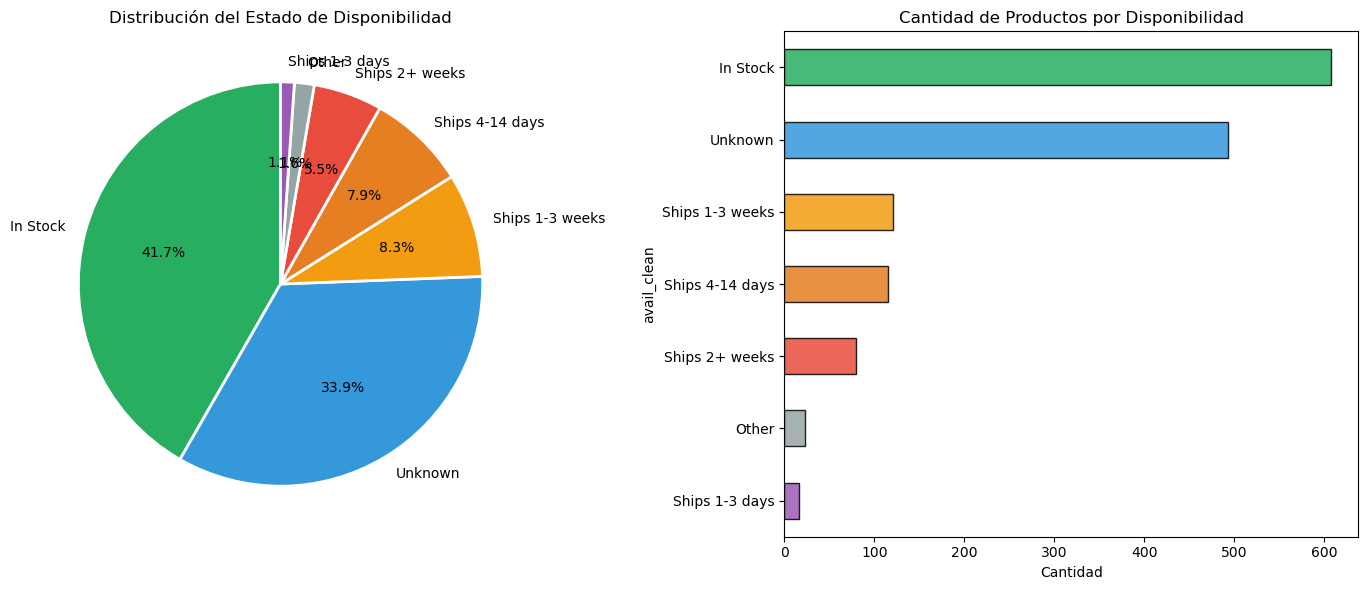

In [27]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================
import matplotlib.pyplot as plt

# Contar la cantidad de productos por cada estado de disponibilidad
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

# Crear una cuadrícula con 2 gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico Izquierdo: Gráfico de Pastel (Distribución Porcentual)
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución del Estado de Disponibilidad')

# 2. Gráfico Derecho: Gráfico de Barras Horizontales (Conteo Absoluto)
avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Cantidad de Productos por Disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

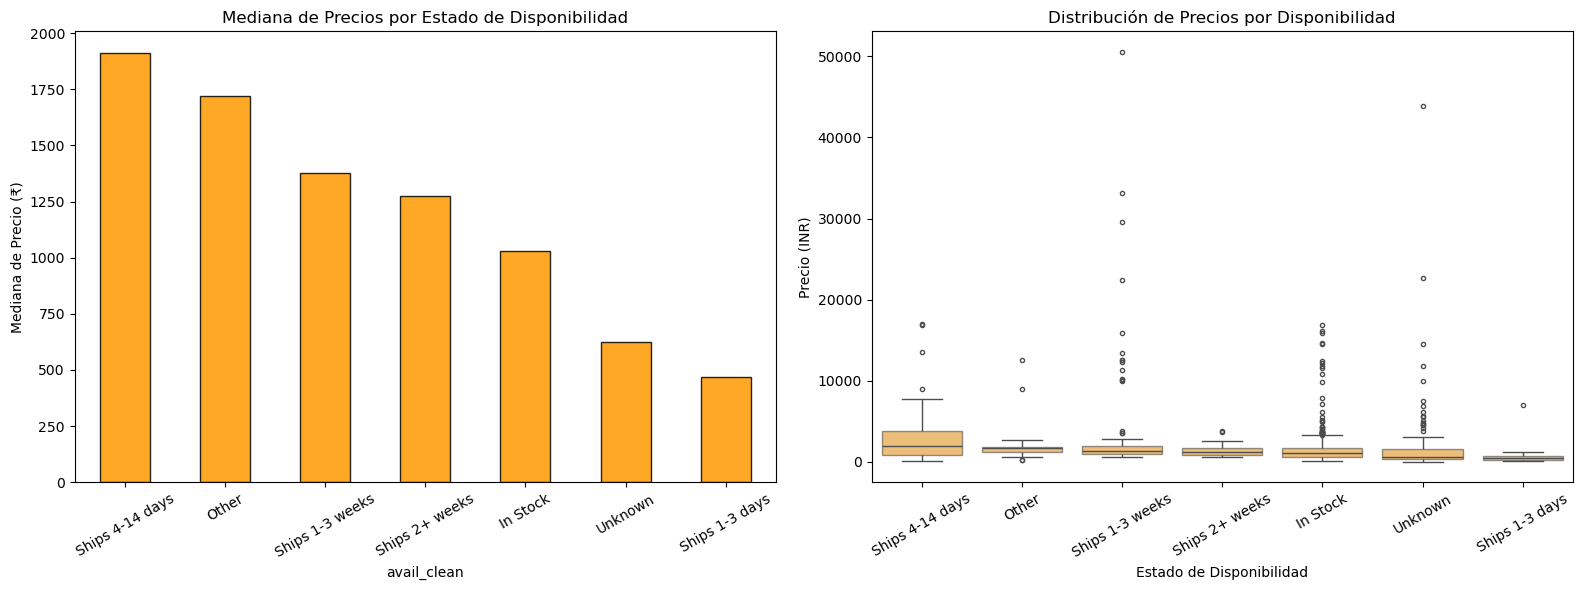

Precio por disponibilidad:
                 Mediana   Media  Cantidad
avail_clean                               
Ships 4-14 days   1912.3  2874.6       115
Other             1718.0  2353.3        21
Ships 1-3 weeks   1377.0  3231.6       121
Ships 2+ weeks    1273.0  1385.9        80
In Stock          1030.0  1490.5       599
Unknown            624.5  1861.9       144
Ships 1-3 days     469.0   874.9        16


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar por estado de disponibilidad y calcular estadísticas de precios
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
# Filtrar para incluir solo estados con 5 o más productos y ordenar por la mediana
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

# Configurar el tamaño de la figura (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico Izquierdo: Mediana de Precios por Estado de Disponibilidad
avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precios por Estado de Disponibilidad')
axes[0].set_ylabel('Mediana de Precio (₹)')
axes[0].tick_params(axis='x', rotation=30)

# 2. Gráfico Derecho: Diagrama de caja (Boxplot) optimizado con SEABORN (Evita errores en rojo)
# Filtramos el DataFrame para que solo contenga los estados que pasaron el filtro (count >= 5)
df_filtrado_avail = df_priced[df_priced['avail_clean'].isin(avail_price.index)]

sns.boxplot(
    data=df_filtrado_avail,
    x='avail_clean',
    y='price_clean',
    ax=axes[1],
    order=avail_price.index,     # Mantiene el mismo orden que el gráfico de barras
    color='#FF9900',             # Color naranja de Amazon
    boxprops=dict(alpha=0.6),    # Aplica la transparencia de forma segura
    fliersize=3
)

axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_xlabel('Estado de Disponibilidad')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Renombrar columnas para la visualización final del print en español
avail_price_es = avail_price.rename(columns={'mean': 'Media', 'median': 'Mediana', 'count': 'Cantidad'})
print('Precio por disponibilidad:')
print(avail_price_es.to_string())

## 7. Correlación y Análisis Bivariado 🔗 <a id='s7'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre del producto predice su precio?
</div>

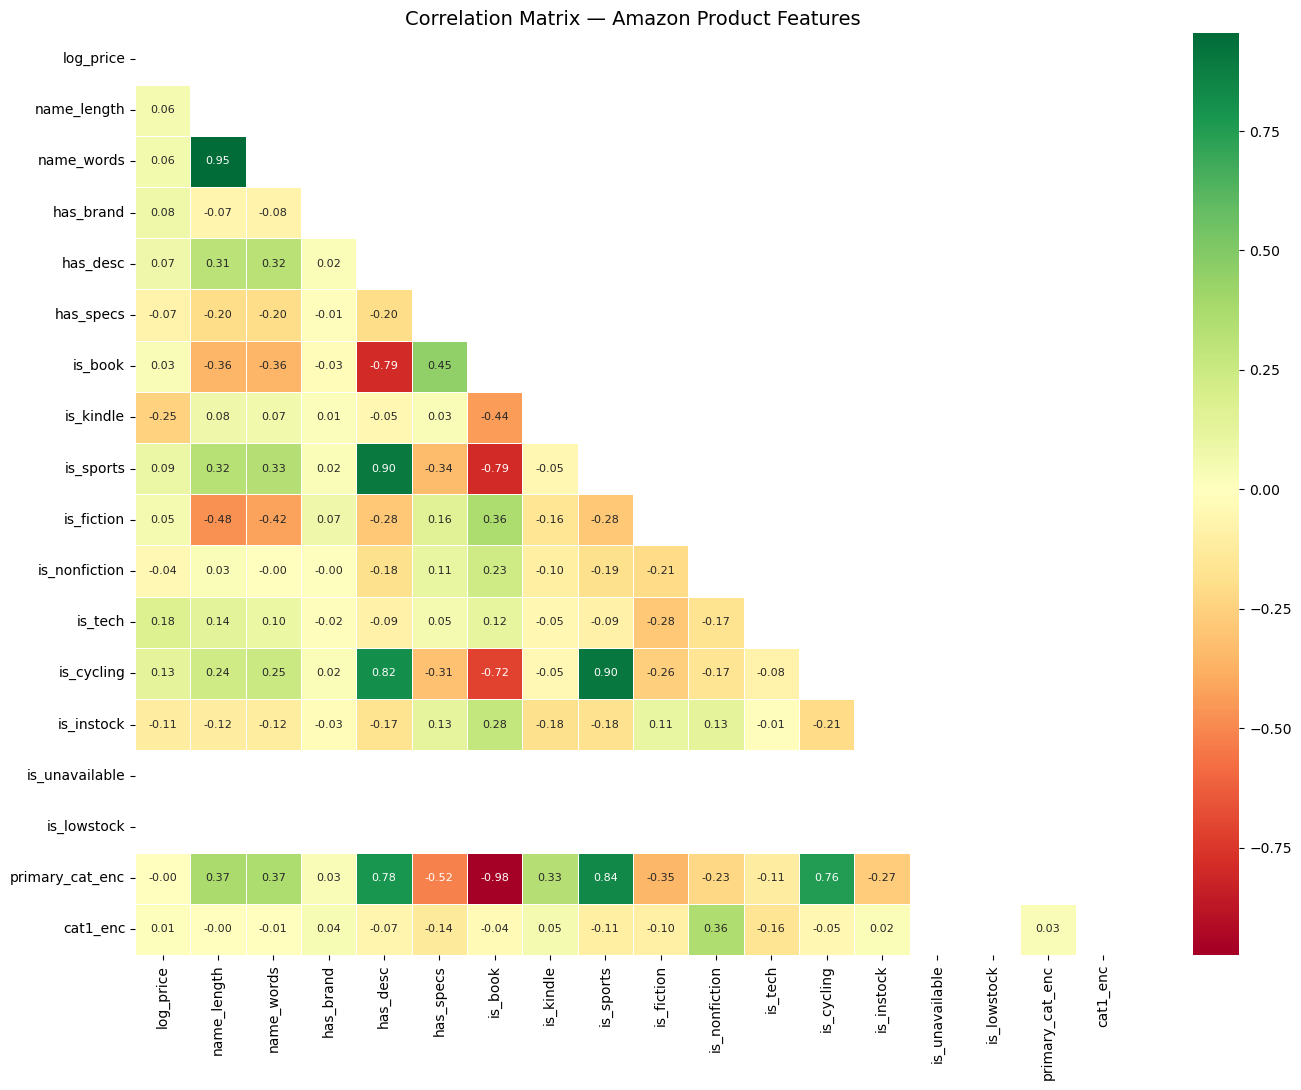

Top correlations with log_price:
is_tech            0.176037
is_cycling         0.126183
is_sports          0.091306
has_brand          0.083746
has_desc           0.074759
name_words         0.060378
name_length        0.055489
is_fiction         0.051518
is_book            0.030592
cat1_enc           0.005744
primary_cat_enc   -0.003885
is_nonfiction     -0.044976
has_specs         -0.072708
is_instock        -0.114351
is_kindle         -0.246437
is_unavailable          NaN
is_lowstock             NaN


In [33]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

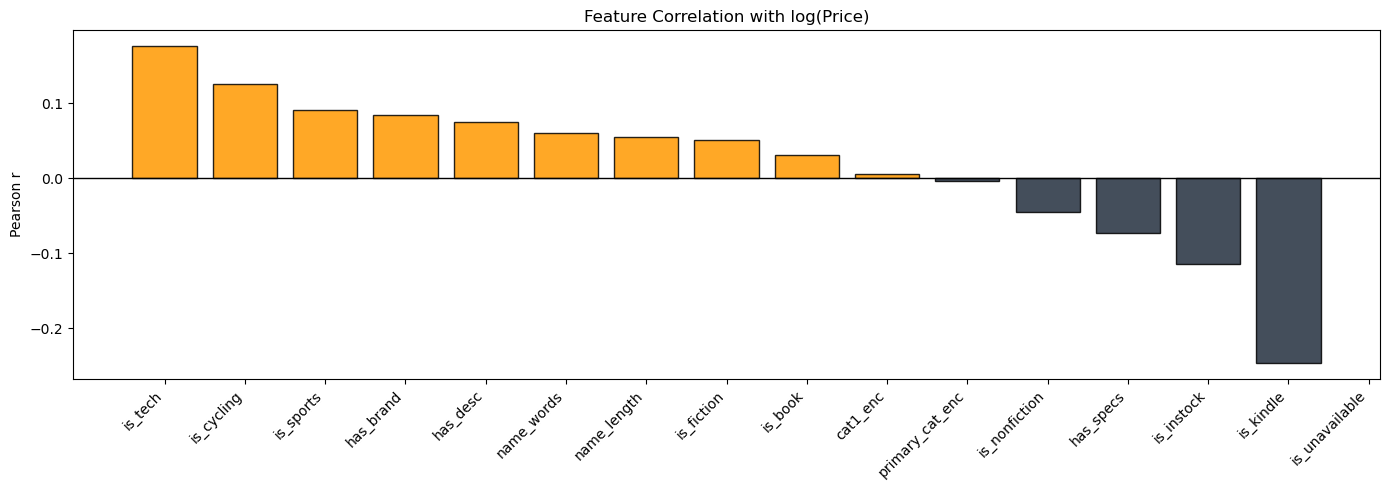

In [30]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


C:\Users\PC-13\AppData\Local\Temp\ipykernel_15392\3232008277.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),


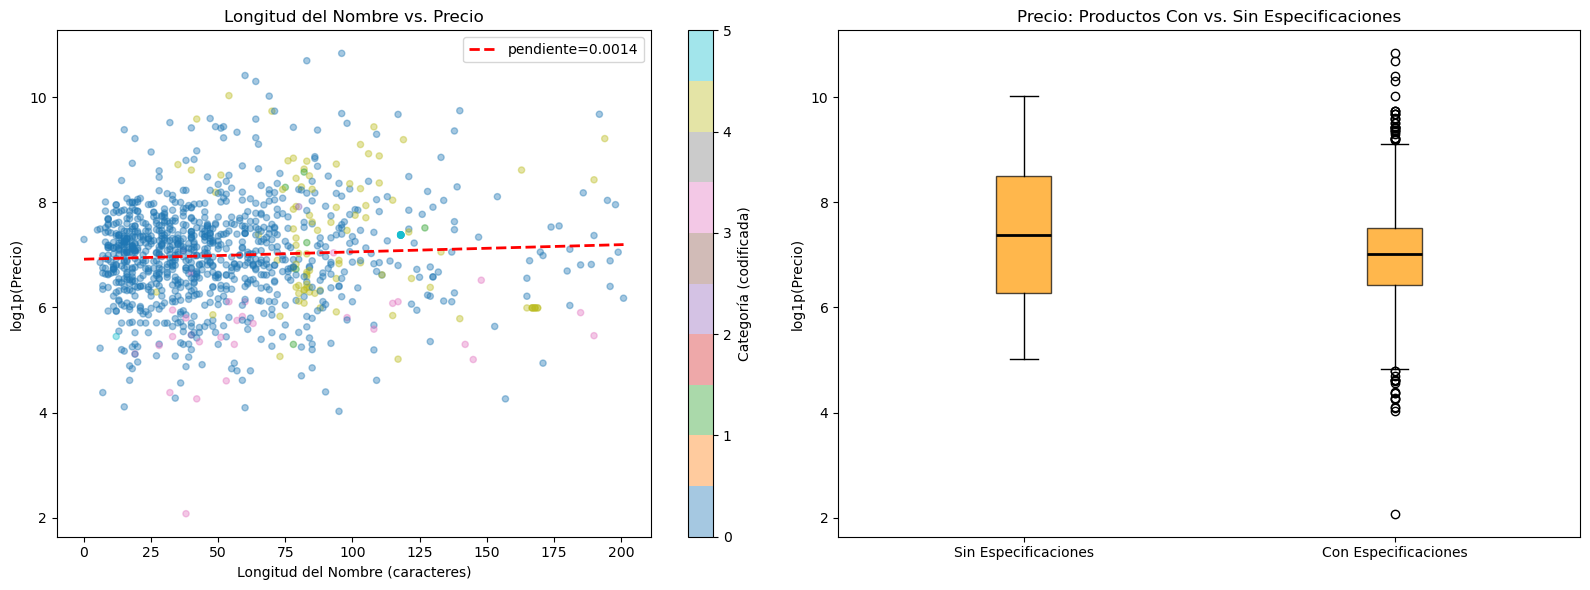

In [38]:
# Gráfico de dispersión: longitud del nombre vs. precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')

# Ajuste de la línea de tendencia
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')

axes[0].set_xlabel('Longitud del Nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs. Precio')
axes[0].legend()

# Gráfico de caja: Precio según si tiene especificaciones o no
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['Sin Especificaciones', 'Con Especificaciones'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Precio: Productos Con vs. Sin Especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()